Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<ipython-input-2-94aff0794119>:49: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CasNumber'].fillna('Unknown', inplace=True)
<ipython-input-2-94aff0794119>:53: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

Accuracy: 0.9996
Classification Report:
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00      7257
      Unsafe       1.00      0.99      0.99       296

    accuracy                           1.00      7553
   macro avg       1.00      0.99      1.00      7553
weighted avg       1.00      1.00      1.00      7553



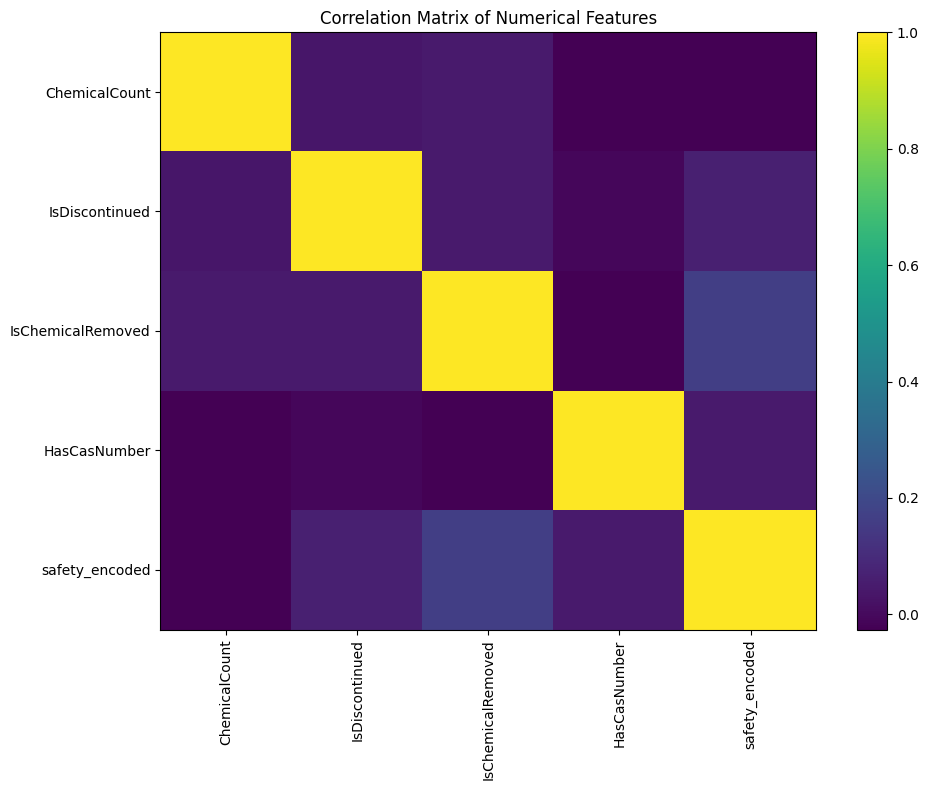

In [2]:
# cosmetics_pipeline.py
# A streamlined pipeline for classifying cosmetic chemicals as safe or unsafe

from google.colab import drive
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt


def mount_drive(path: str = '/content/drive') -> None:
    """Mount Google Drive in Google Colab."""
    drive.mount(path)


def load_data(filepath: str) -> pd.DataFrame:
    """Load the chemicals-in-cosmetics dataset from CSV."""
    return pd.read_csv(filepath)


def label_safety(df: pd.DataFrame, unsafe_list: list) -> pd.DataFrame:
    """Add a binary 'safety' label based on presence of known unsafe chemicals."""
    def check_safety(name: str) -> str:
        return 'Unsafe' if any(u.lower() in name.lower() for u in unsafe_list) else 'Safe'
    df['safety'] = df['ChemicalName'].apply(check_safety)
    return df


def encode_target(df: pd.DataFrame) -> pd.DataFrame:
    """Encode the 'safety' column into numeric labels."""
    le = LabelEncoder()
    df['safety_encoded'] = le.fit_transform(df['safety'])
    return df, le


def feature_engineering(df: pd.DataFrame) -> pd.DataFrame:
    """Perform cleaning, feature creation, and drop unused columns."""
    # Discontinued and removed flags
    df['IsDiscontinued'] = df['DiscontinuedDate'].notnull().astype(int)
    df['IsChemicalRemoved'] = df['ChemicalDateRemoved'].notnull().astype(int)

    # Drop original date columns
    df.drop(['DiscontinuedDate', 'ChemicalDateRemoved', 'CSFId', 'CSF'],
            axis=1, inplace=True)

    # CAS number flag
    df['CasNumber'].fillna('Unknown', inplace=True)
    df['HasCasNumber'] = (df['CasNumber'] != 'Unknown').astype(int)

    # BrandName missing as 'Unknown'
    df['BrandName'].fillna('Unknown', inplace=True)

    # Remove duplicate rows
    df.drop_duplicates(inplace=True)

    # Aggregate duplicates by product and chemical
    df = df.groupby(['ProductName', 'ChemicalName'], as_index=False).agg({
        'ChemicalCount': 'sum',
        'BrandName': 'first',
        'CasNumber': 'first',
        'PrimaryCategory': 'first',
        'IsDiscontinued': 'max',
        'IsChemicalRemoved': 'max',
        'HasCasNumber': 'max',
        'safety_encoded': 'first'
    })

    return df


def encode_categoricals(X_train: pd.DataFrame, X_test: pd.DataFrame,
                         cat_cols: list) -> tuple:
    """Label encode all categorical columns consistently on train and test."""
    # Create a single LabelEncoder instance for each categorical column
    # to ensure consistent encoding across train and test sets.
    encoders = {}
    for col in cat_cols:
        encoders[col] = LabelEncoder()  # Create a new encoder for this column
        # Fit on the combined unique values from both train and test
        all_values = pd.concat([X_train[col], X_test[col]]).unique()
        encoders[col].fit(all_values.astype(str))

        # Transform train and test separately
        X_train[col] = encoders[col].transform(X_train[col].astype(str))
        X_test[col] = encoders[col].transform(X_test[col].astype(str))

    return X_train, X_test


def train_evaluate(X_train: pd.DataFrame, y_train: pd.Series,
                   X_test: pd.DataFrame, y_test: pd.Series) -> None:
    """Train RandomForest and print evaluation metrics."""
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Safe', 'Unsafe']))


def plot_correlation(df: pd.DataFrame) -> None:
    """Plot correlation matrix for numeric features."""
    numeric_df = df.select_dtypes(include='number')
    corr = numeric_df.corr()
    plt.figure(figsize=(10, 8))
    plt.title('Correlation Matrix of Numerical Features')
    plt.imshow(corr, interpolation='nearest', aspect='auto')
    plt.colorbar()
    plt.xticks(range(len(corr)), corr.columns, rotation=90)
    plt.yticks(range(len(corr)), corr.index)
    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    # Paths
    data_path = '/content/drive/MyDrive/ml project/chemicals-in-cosmetics.csv'

    # Execution pipeline
    mount_drive()
    df = load_data(data_path)

    unsafe_list = [
        'Parabens', 'Formaldehyde', 'Phthalates', 'Triclosan',
        'Sodium Lauryl Sulfate', 'Toluene', 'Lead', 'Mercury',
        'Petrolatum', 'Coal Tar', 'Ethanolamine'
    ]

    df = label_safety(df, unsafe_list)
    df, target_encoder = encode_target(df)
    df = feature_engineering(df)

    # Split
    X = df.drop('safety_encoded', axis=1)
    y = df['safety_encoded']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Encode categoricals
    categorical_columns = ['ProductName', 'ChemicalName', 'BrandName',
                           'CasNumber', 'PrimaryCategory']
    X_train, X_test = encode_categoricals(X_train, X_test, categorical_columns)

    # Train and evaluate
    train_evaluate(X_train, y_train, X_test, y_test)

    # Correlation plot
    plot_correlation(df)
